# Test spectrum of a system

[0.09729378 0.87564401]


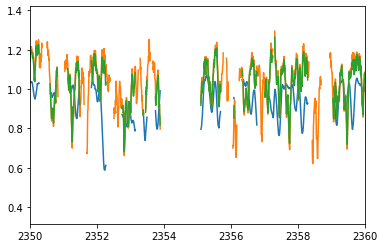

In [1]:
# make test spectrum of system: 50% ROXs12A + 50% 2M0355

import numpy as np
import matplotlib.pyplot as plt

def load_spec_file(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=file[:,0]
    fl=file[:,1]
    flerr=file[:,2]
    return wl,fl,flerr

wlA,flA,flerrA=load_spec_file('/home/natalie/Desktop/atm_retrieval/ROXs12A/ROXs12A_spectrum.txt')
wlB,flB,flerrB=load_spec_file('/home/natalie/Desktop/atm_retrieval/2M0355/2M0355_spectrum.txt')

# interpolate wl of B onto A
flB_interp = np.interp(wlA, wlB, flB)
errB_interp = np.interp(wlA, wlB, flerrB)

# add A+B
ratioA = 0.1 # for testing other scenarios
ratioB = 1-ratioA
flux = ratioA*flA+ratioB*flB
err = np.sqrt(flerrA**2+errB_interp**2)
plt.plot(wlA,flA)
plt.plot(wlB,flB)
plt.plot(wlA,flux)
plt.xlim(2350,2360)
flux/=np.nanmedian(flux) # normalize again

spectrum=np.full(shape=(3*7*2048,3),fill_value=np.nan)
spectrum[:,0]=wlA
spectrum[:,1]=flux
spectrum[:,2]=err.flatten()
#np.savetxt('./testsys/testsys_spectrum.txt',spectrum,delimiter=' ',header='wavelength (nm) flux flux_error')

# test if correct fit can be retrieved
from scipy.optimize import nnls

# ignore nans for least squares
nonans = np.isfinite(flux) & np.isfinite(flA) & np.isfinite(flB_interp) & np.isfinite(flerrA) & np.isfinite(errB_interp)
M = np.vstack([flA[nonans], flB[nonans]]).T # create model matrix, shape (2, N)
d = flux[nonans] # data
inv_cov = np.diag(1/err[nonans]**2) # define inverse of covariance matrix

# set up equation to solve (see Ruffio+2019 Appendix A)
lhs = M.T @ inv_cov @ M # left-hand side
rhs = M.T @ inv_cov @ d # right-hand side
phi, _ = nnls(lhs, rhs)
print(phi)

# Other

In [1]:
# spectral resolution

from target import Target
bd = Target('ROXs12A')
wl,fl,err = bd.load_spectrum()
res = bd.calc_resolution()
print(res) # mean
print(bd.spec_resolution) # all order/dets

63088.33998377872
[[59715.61116754 62974.89338345 66760.03257009]
 [59744.87789753 63036.87023503 66853.63374988]
 [59799.19780577 63061.49268731 66855.46321002]
 [59849.43383351 63088.33998378 66869.18642593]
 [59890.6650157  63139.14285322 66908.99453152]
 [59932.13264088 63190.48324078 66959.06158776]
 [59974.65773933 63273.27416509 67044.81768477]]
